# Validation 1: the Sun–Jupiter–Saturn system

A test of the method on a system whose answer is known: Jupiter and Saturn are stable. The notebook checks (1) energy conservation with the WHFast integrator and (2) the MEGNO chaos indicator, including a stability map of Saturn's possible orbits that recovers the mean-motion resonances with Jupiter.

Units: years, AU and solar masses.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import rebound

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("REBOUND version:", rebound.__version__)

REBOUND version: 5.2.0


## 1. The system

Approximate present-day masses, semi-major axes *a* and eccentricities *e*. Saturn's orbit is a parameter, so that it can be moved for the stability map.

In [2]:
M_JUP, A_JUP, E_JUP = 9.5479e-4, 5.2044, 0.0489   # Jupiter: mass (solar masses), semi-major axis (AU), eccentricity
M_SAT, A_SAT, E_SAT = 2.8589e-4, 9.5826, 0.0565   # Saturn

def build_system(a_sat=A_SAT, e_sat=E_SAT, m_sat=M_SAT):
    # Sun-Jupiter-Saturn simulation; a_sat, e_sat and m_sat move or rescale Saturn.
    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    sim.add(m=1.0)                         # Sun
    sim.add(m=M_JUP, a=A_JUP, e=E_JUP)     # Jupiter
    sim.add(m=m_sat, a=a_sat, e=e_sat)     # Saturn
    sim.move_to_com()                      # center-of-mass frame
    sim.integrator = "whfast"              # Wisdom-Holman symplectic integrator
    sim.dt = 0.05 * sim.particles[1].P     # time step = 5% of Jupiter's period
    return sim

sim = build_system()
jupiter, saturn = sim.particles[1], sim.particles[2]
print(f"One Jupiter orbit takes {jupiter.P:.2f} years")
print(f"One Saturn orbit takes  {saturn.P:.2f} years")
print(f"Saturn/Jupiter ratio:   {saturn.P / jupiter.P:.3f}")

One Jupiter orbit takes 11.87 years
One Saturn orbit takes  29.65 years
Saturn/Jupiter ratio:   2.498


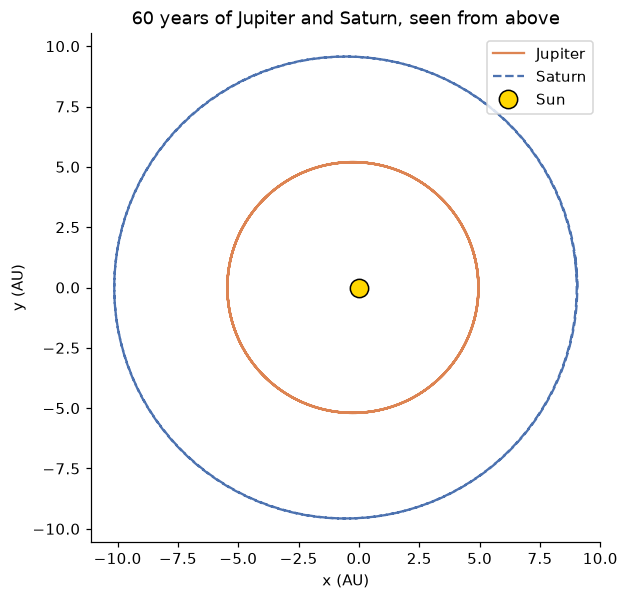

In [3]:
# Heliocentric positions over 60 years.
sim = build_system()
times = np.linspace(0, 60, 600)
path = np.zeros((len(times), 3, 2))
for i, t in enumerate(times):
    sim.integrate(t)   # exact output times give smooth orbit tracks
    sun = sim.particles[0]
    for k in range(3):
        p = sim.particles[k]
        path[i, k] = (p.x - sun.x, p.y - sun.y)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(path[:, 1, 0], path[:, 1, 1], color="#DD8452", label="Jupiter")
ax.plot(path[:, 2, 0], path[:, 2, 1], color="#4C72B0", ls="--", label="Saturn")
ax.plot(0, 0, "o", color="gold", markersize=12, markeredgecolor="black", label="Sun")
ax.set_aspect("equal")
ax.set_xlabel("x (AU)")
ax.set_ylabel("y (AU)")
ax.set_title("60 years of Jupiter and Saturn, seen from above")
ax.legend(loc="upper right")
plt.show()

## 2. Energy conservation

The total energy of an isolated system is conserved, so the relative energy error |ΔE/E₀| measures the integration error. The same 100,000 years are integrated with time steps of 5% and 20% of Jupiter's period.

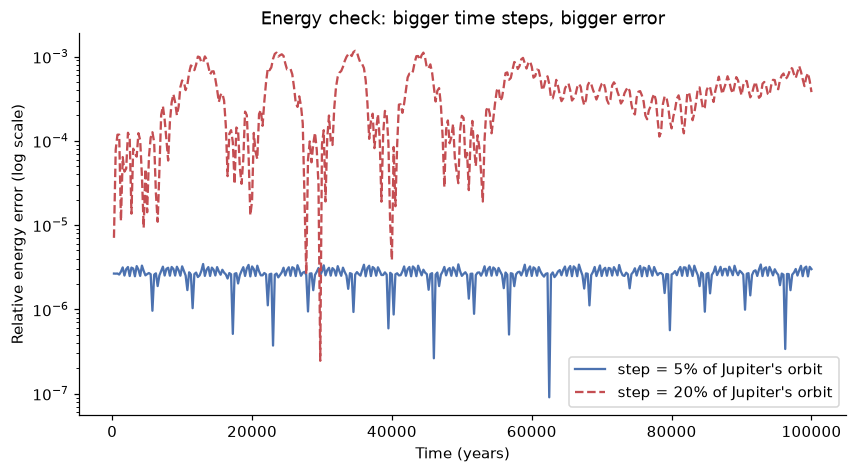

Worst error with 5% steps:  3.5e-06
Worst error with 20% steps: 1.2e-03
The big steps are 339 times worse.


In [4]:
def energy_error_history(step_fraction, years=100_000, samples=400):
    # Runs the real system with time step = step_fraction x one Jupiter orbit.
    # Returns the times and the relative energy error at each time.
    sim = build_system()
    sim.dt = step_fraction * sim.particles[1].P
    E0 = sim.energy()
    times = np.linspace(years / samples, years, samples)
    errors = []
    for t in times:
        sim.integrate(t, exact_finish_time=0)
        errors.append(abs((sim.energy() - E0) / E0))
    return times, np.array(errors)

t_small, err_small = energy_error_history(0.05)   # 5% of Jupiter's orbit per step
t_big, err_big = energy_error_history(0.20)       # 20% per step

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(t_small, err_small, color="#4C72B0", label="step = 5% of Jupiter's orbit")
ax.semilogy(t_big, err_big, color="#C44E52", ls="--", label="step = 20% of Jupiter's orbit")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Relative energy error (log scale)")
ax.set_title("Energy check: bigger time steps, bigger error")
ax.legend(loc="lower right")
plt.show()

print(f"Worst error with 5% steps:  {err_small.max():.1e}")
print(f"Worst error with 20% steps: {err_big.max():.1e}")
print(f"The big steps are {err_big.max() / err_small.max():.0f} times worse.")

### Other step sizes

In [5]:
for step_fraction in [0.10, 0.35]:
    _, err = energy_error_history(step_fraction)
    print(f"step = {step_fraction:.0%} of Jupiter's orbit  ->  worst error {err.max():.1e}")

step = 10% of Jupiter's orbit  ->  worst error 1.5e-05
step = 35% of Jupiter's orbit  ->  worst error 2.9e-04


The error is not monotonic in the step size (35% gives a smaller error than 20% here), so it has to be measured for each setup rather than assumed.

## 3. MEGNO chaos indicator

MEGNO (Mean Exponential Growth factor of Nearby Orbits; Cincotta & Simó 2000) follows how an infinitesimally displaced copy of the system diverges from it. For regular (quasi-periodic) motion it converges to 2; for chaotic motion it keeps growing. Runs that end in a close approach or an ejection are assigned the maximum value, 8.

In [6]:
MAX_SCORE = 8.0

def chaos_score(a_sat, e_sat, m_sat=M_SAT, jupiter_orbits=5000):
    # MEGNO for Sun-Jupiter-Saturn with Saturn placed at distance a_sat and eccentricity e_sat.
    # About 2 = orderly. Clearly above 2 = chaotic. 8 = unstable (close pass or ejection).
    # Default run: 5,000 Jupiter orbits, about 59,000 years.
    sim = build_system(a_sat, e_sat, m_sat)
    sim.exit_max_distance = 30.0   # stop if a planet is flung beyond 30 AU
    sim.exit_min_distance = 0.3    # stop if the planets pass within 0.3 AU of each other
    sim.init_megno(seed=1)         # fixed seed for reproducible MEGNO values
    try:
        sim.integrate(jupiter_orbits * sim.particles[1].P, exact_finish_time=0)
        return min(sim.megno(), MAX_SCORE)
    except (rebound.Escape, rebound.Encounter):
        return MAX_SCORE

print(f"Real Saturn ({A_SAT} AU):  chaos score = {chaos_score(A_SAT, E_SAT):.2f}")
print(f"Saturn moved to 6.3 AU:   chaos score = {chaos_score(6.3, E_SAT):.2f}")

Real Saturn (9.5826 AU):  chaos score = 1.85
Saturn moved to 6.3 AU:   chaos score = 8.00


Three other positions of Saturn:

In [7]:
for a, e in [(7.0, 0.05), (8.3, 0.06), (9.0, 0.25)]:
    print(f"Saturn at a = {a} AU, e = {e}:  chaos score = {chaos_score(a, e):.2f}")

Saturn at a = 7.0 AU, e = 0.05:  chaos score = 2.01
Saturn at a = 8.3 AU, e = 0.06:  chaos score = 6.86
Saturn at a = 9.0 AU, e = 0.25:  chaos score = 8.00


## 4. Stability map

MEGNO on a grid of 40 semi-major axes × 30 eccentricities for Saturn (1,200 integrations of 5,000 Jupiter orbits). Dotted lines mark mean-motion resonances with Jupiter, placed with Kepler's third law; the star marks the real Saturn.

In [8]:
def make_map(a_values, e_values, m_sat=M_SAT, jupiter_orbits=5000):
    # Chaos score for every (distance, eccentricity) pair in the grid.
    grid = np.zeros((len(e_values), len(a_values)))
    start = time.time()
    for i, e in enumerate(e_values):
        for j, a in enumerate(a_values):
            grid[i, j] = chaos_score(a, e, m_sat, jupiter_orbits)
        print(f"\rrow {i + 1}/{len(e_values)} done", end="")
    print(f"\nFinished in {time.time() - start:.0f} seconds")
    return grid

def plot_map(a_values, e_values, grid, title, filename=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    mesh = ax.pcolormesh(a_values, e_values, grid, vmin=1.9, vmax=4.0,
                         cmap="viridis", shading="nearest")
    fig.colorbar(mesh, ax=ax, label="Chaos score (MEGNO): about 2 = orderly, higher = chaotic")
    top = e_values.max()
    for p, q in [(3, 2), (5, 3), (2, 1), (7, 3), (5, 2)]:
        a_res = A_JUP * (p / q) ** (2 / 3)          # Kepler's third law
        if a_values.min() <= a_res <= a_values.max():
            ax.axvline(a_res, color="white", ls=":", lw=1)
            ax.text(a_res, top * 1.02, f"{p}:{q}", ha="center", va="bottom", fontsize=9)
    if a_values.min() <= A_SAT <= a_values.max() and E_SAT <= top:
        ax.plot(A_SAT, E_SAT, marker="*", markersize=18, color="white",
                markeredgecolor="black", ls="none", label="Real Saturn")
        ax.legend(loc="upper left")
    ax.set_xlabel("Saturn's average distance from the Sun (AU)")
    ax.set_ylabel("Saturn's eccentricity (0 = circle)")
    ax.set_title(title, pad=22)
    if filename:
        plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

a_values = np.linspace(6.0, 10.5, 40)
e_values = np.linspace(0.0, 0.40, 30)
chaos_map = make_map(a_values, e_values)

row 30/30 done
Finished in 38 seconds


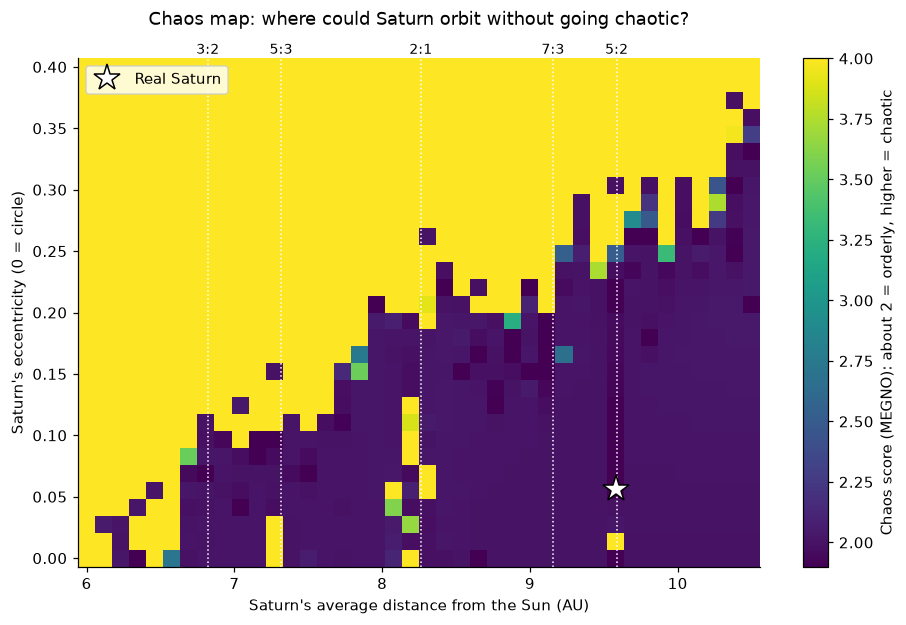

In [9]:
plot_map(a_values, e_values, chaos_map,
         "Chaos map: where could Saturn orbit without going chaotic?",
         filename="chaos_map_jupiter_saturn.png")

## Result

With a time step of 5% of Jupiter's period, the relative energy error stays below 4 × 10⁻⁶ over 100,000 years. The real Saturn lies in a regular region (MEGNO close to 2; 1.85 in this run), next to the 5:2 resonance (period ratio 2.498). Chaos and instability dominate at high eccentricity, where Saturn's perihelion approaches Jupiter's orbit, and narrow chaotic strips appear at resonances: at 8.3 AU, near the 2:1 resonance, MEGNO is well above 2 (6.86 in this run) although the two orbits stay far apart. Individual MEGNO values differ slightly between machines because of floating-point rounding; the regular or chaotic classification does not.